# 5.2

## Imports and configuration

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt


if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f'Device: CUDA GPU, {torch.cuda.get_device_name(0)}')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
    print('Device: Apple Silicon MPS')
else:
    device = torch.device('cpu')
    print('Device: CPU')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# display a grid of generated images
def show_images(images, n_row=4, n_col=8, title='Generated samples', figsize=(12, 6)):
    images = images.detach().cpu()
    # normalise to [0, 1]
    images = (images - images.min()) / (images.max() - images.min() + 1e-8)
    
    if images.dim() == 4 and images.shape[1] == 1:
        images = images.squeeze(1) # grayscale: remove channel dim
        
    n = min(n_row * n_col, images.shape[0])
    fig, axes = plt.subplots(n_row, n_col, figsize=figsize)
    for i, ax in enumerate(axes.flat):
        if i < n:
            img = images[i].numpy()
            # (H, W, C) for matplotlib
            if img.shape[0] == 3:
                img = np.transpose(img, (1, 2, 0))
            ax.imshow(img, cmap='gray' if images.dim() == 3 else None)
            ax.axis('off')
            
    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

Device: CPU


## DCGAN architecture

In [2]:
IMG_SIZE = 32
NC = 3          # num of channels
NGF = 64        # generator feature map size
NDF = 64        # discriminator feature map size
Z_DIM_DC = 100

def weights_init(m):
    # Initialise conv and batchnorm weights
    classname = m.__class__.__name__
    if 'Conv' in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif 'BatchNorm' in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

class DCGenerator(nn.Module):
    # Produces 3x32x32 images. Architecture: z -> [4x4] -> [8x8] -> [16x16] -> [32x32]
    def __init__(self, z_dim, ngf, nc):
        super().__init__()
        self.main = nn.Sequential(
            # input: (z_dim, 1, 1)
            nn.ConvTranspose2d(z_dim, ngf * 4, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            # (ngf*4, 4, 4)
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            # (ngf*2, 8, 8)
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            # (ngf, 16, 16)
            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh()
            # (nc, 32, 32)
        )

    def forward(self, z):
        return self.main(z)

class DCDiscriminator(nn.Module):
    # Receives 3x32x32 images, outputs scalar in (0,1)
    def __init__(self, nc, ndf):
        super().__init__()
        self.main = nn.Sequential(
            # (nc, 32, 32)
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # (ndf, 16, 16)
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # (ndf*2, 8, 8)
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # (ndf*4, 4, 4)
            nn.Conv2d(ndf * 4, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
            # (1, 1, 1)
        )

    def forward(self, x):
        return self.main(x).view(-1, 1)

netG_dc = DCGenerator(Z_DIM_DC, NGF, NC).to(device).apply(weights_init)
netD_dc = DCDiscriminator(NC, NDF).to(device).apply(weights_init)

print('DCGAN Generator params: ', sum(p.numel() for p in netG_dc.parameters()))
print('DCGAN Discriminator params: ', sum(p.numel() for p in netD_dc.parameters()))

DCGAN Generator params:  1068928
DCGAN Discriminator params:  663296


## Data loading and preparation

In [3]:
LR = 2e-4
BATCH = 128

transform_dc = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # normalise to 3 channels
])

# loading CIFAR-10 dataset
cifar_dc = datasets.CIFAR10(root='./data', train=True, transform=transform_dc, download=True)
loader_dc = DataLoader(cifar_dc, batch_size=BATCH, shuffle=True, drop_last=True)

# fixed noise
fixed_noise_dc = torch.randn(32, Z_DIM_DC, 1, 1, device=device)

opt_D_dc = optim.Adam(netD_dc.parameters(), lr=LR, betas=(0.5, 0.999))
opt_G_dc = optim.Adam(netG_dc.parameters(), lr=LR, betas=(0.5, 0.999))

C:\Users\zawer\documents\applied_math\sem1\machine_learning\assingments\ml_assingments_venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


## Main learning loop

In [4]:
EPOCHS_DC = 15
bce_dc = nn.BCELoss()

hist_D_dc, hist_G_dc = [], []

for epoch in range(EPOCHS_DC):
    loss_D_sum = 0.0
    loss_G_sum = 0.0
    
    for real, _ in loader_dc:
        m = real.size(0)
        real = real.to(device)
        
        ones = torch.ones(m, 1, device=device)
        zeros = torch.zeros(m, 1, device=device)
        
        # ---- Update D ----
        z = torch.randn(m, Z_DIM_DC, 1, 1, device=device)
        fake = netG_dc(z).detach()
        
        loss_D = bce_dc(netD_dc(real), ones) + bce_dc(netD_dc(fake), zeros)
        
        opt_D_dc.zero_grad()
        loss_D.backward()
        opt_D_dc.step()
        
        # ---- Update G ----
        z = torch.randn(m, Z_DIM_DC, 1, 1, device=device)
        fake = netG_dc(z)
        
        loss_G = bce_dc(netD_dc(fake), ones)
        
        opt_G_dc.zero_grad()
        loss_G.backward()
        opt_G_dc.step()
        
        loss_D_sum += loss_D.item()
        loss_G_sum += loss_G.item()
        
    avg_D = loss_D_sum / len(loader_dc)
    avg_G = loss_G_sum / len(loader_dc)
    
    hist_D_dc.append(avg_D)
    hist_G_dc.append(avg_G)
    
    # logs in terminal
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f'Epoch [{epoch+1:3d}/{EPOCHS_DC}] loss_D: {avg_D:.4f} loss_G: {avg_G:.4f}')

print('DCGAN training complete.')

Epoch [  1/15] loss_D: 0.3503 loss_G: 5.4179
Epoch [  5/15] loss_D: 0.5206 loss_G: 2.9007
Epoch [ 10/15] loss_D: 0.6938 loss_G: 2.2509
Epoch [ 15/15] loss_D: 0.6919 loss_G: 2.0775
DCGAN training complete.


## Visualization

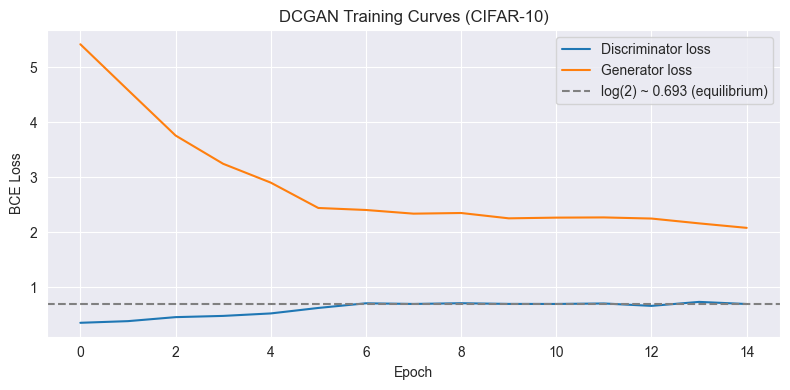

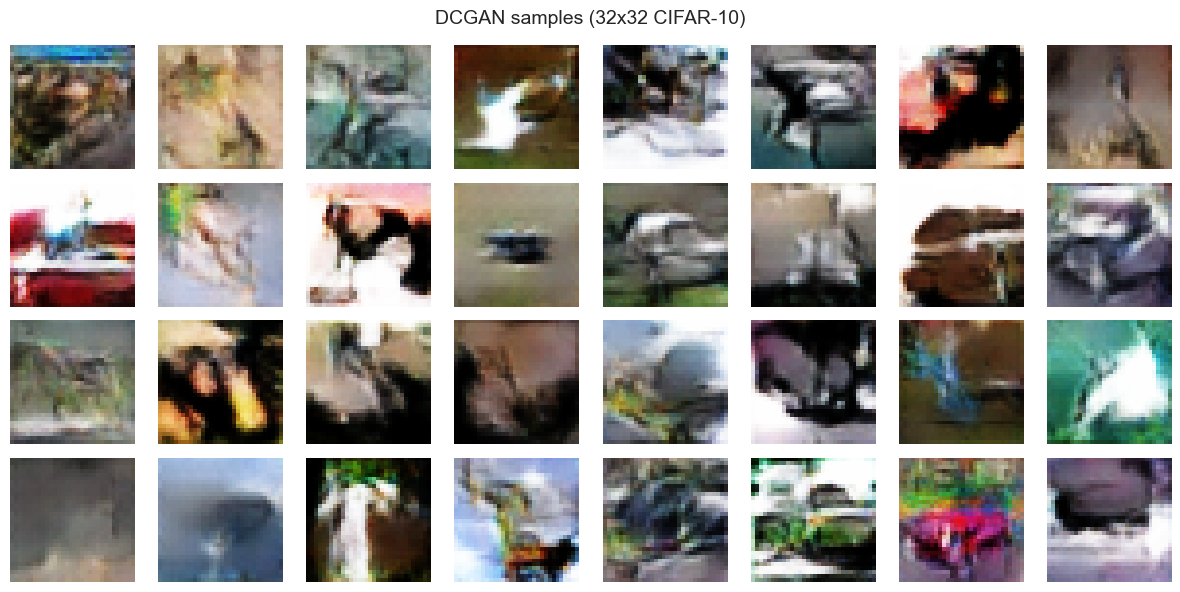

In [5]:
# visualization of losses
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(hist_D_dc, label='Discriminator loss')
ax.plot(hist_G_dc, label='Generator loss')
ax.axhline(y=np.log(2), color='gray', linestyle='--', label='log(2) ~ 0.693 (equilibrium)')
ax.set_xlabel('Epoch')
ax.set_ylabel('BCE Loss')
ax.set_title('DCGAN Training Curves (CIFAR-10)')
ax.legend()
plt.tight_layout()
plt.show()

# visulization of generated images
netG_dc.eval()
with torch.no_grad():
    dc_samples = netG_dc(fixed_noise_dc)

show_images(dc_samples, n_row=4, n_col=8, title='DCGAN samples (32x32 CIFAR-10)')

## FID-like

In [6]:
from scipy import linalg


def compute_fid_like(real_loader, gen_model, z_dim, n_samples=2000, device='cpu'):
    real_feats, fake_feats = [], []
    gen_model.eval()
    
    with torch.no_grad():
        # collecting pixels of real images
        for batch, _ in real_loader:
            real_feats.append(batch.view(batch.size(0), -1).numpy())
            if len(np.concatenate(real_feats)) >= n_samples:
                break
                
        # collecting pixels of generated data
        collected = 0
        while collected < n_samples:
            bs = min(256, n_samples - collected)
            z = torch.randn(bs, z_dim, 1, 1, device=device)
            # CIFAR vector 3x32x32 = 3072
            fake = gen_model(z).cpu().view(bs, -1).numpy()
            fake_feats.append(fake)
            collected += bs
            
    real_feats = np.concatenate(real_feats)[:n_samples]
    fake_feats = np.concatenate(fake_feats)[:n_samples]
    
    # statistics
    mu_r, mu_g = real_feats.mean(axis=0), fake_feats.mean(axis=0)
    sigma_r = np.cov(real_feats, rowvar=False)
    sigma_g = np.cov(fake_feats, rowvar=False)
    
    # regularization
    eps = 1e-6
    sigma_r += eps * np.eye(sigma_r.shape[0])
    sigma_g += eps * np.eye(sigma_g.shape[0])
    
    cov_mean = linalg.sqrtm(sigma_r @ sigma_g)
    if np.iscomplexobj(cov_mean):
        cov_mean = cov_mean.real
        
    fid = np.sum((mu_r - mu_g) ** 2) + np.trace(sigma_r + sigma_g - 2.0 * cov_mean)
    return float(fid)

In [7]:
print('Computing FID-like score on pixel features...')

transform_raw = transforms.Compose([
    transforms.Resize(IMG_SIZE), 
    transforms.ToTensor()
])

# test data for CIFAR-10
cifar_raw = datasets.CIFAR10(root='./data', train=False, transform=transform_raw, download=True)
loader_raw = DataLoader(cifar_raw, batch_size=256, shuffle=False)

netG_dc_cpu = netG_dc.to('cpu')

fid_score = compute_fid_like(loader_raw, netG_dc_cpu, Z_DIM_DC, n_samples=2000, device='cpu')

netG_dc.to(device)

print(f'Pixel-space FID-like score: {fid_score:.2f}')
print('(Lower is better; 0 = identical distributions)')

Computing FID-like score on pixel features...
Pixel-space FID-like score: 1310.77
(Lower is better; 0 = identical distributions)


## FID

In [8]:
import torch.nn.functional as F
from torchvision.models import inception_v3, Inception_V3_Weights
from scipy import linalg
from tqdm import tqdm

inception_model = inception_v3(weights=Inception_V3_Weights.DEFAULT, transform_input=True)

inception_model.fc = nn.Identity() 

inception_model = inception_model.to(device)
inception_model.eval()

Inception3(
  (Conv2d_1a_3x3): BasicConv2d(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2a_3x3): BasicConv2d(
    (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2b_3x3): BasicConv2d(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (Conv2d_3b_1x1): BasicConv2d(
    (conv): Conv2d(64, 80, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(80, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_4a_3x3): BasicConv2d(
    (conv): Conv2d(80, 192, kernel_size=(3, 3), stri

In [9]:
def get_inception_features(images, model):
    # resizing from 32x32 to 299x299
    images_resized = F.interpolate(images, size=(299, 299), mode='bilinear', align_corners=False)
    
    with torch.no_grad():
        features = model(images_resized)
        
    return features.cpu().numpy()

In [10]:
def compute_full_fid(real_loader, gen_model, inception, z_dim, n_samples=10000, device='cpu'):
    real_feats, fake_feats = [], []
    gen_model.eval()
    
    print(f"Calculating full FID for {n_samples} samples...")
    
    with torch.no_grad():
        # collecting pixels for real images
        collected_real = 0
        print("Extracting features from real images...")
        for batch, _ in tqdm(real_loader, desc="Real images"):
            batch = batch.to(device)
            feats = get_inception_features(batch, inception)
            real_feats.append(feats)
            collected_real += batch.size(0)
            if collected_real >= n_samples:
                break
                
        # collecting pixels for generated images
        collected_fake = 0
        batch_size_fid = 64
        
        print("Generating and extracting features from fake images...")
        pbar_fake = tqdm(total=n_samples, desc="Fake images")
        
        while collected_fake < n_samples:
            curr_bs = min(batch_size_fid, n_samples - collected_fake)
            z = torch.randn(curr_bs, z_dim, 1, 1, device=device)
            
            fake_images = gen_model(z)
            # scaling
            fake_images_01 = (fake_images + 1.0) / 2.0
            
            feats = get_inception_features(fake_images_01, inception)
            fake_feats.append(feats)
            collected_fake += curr_bs
            
            pbar_fake.update(curr_bs)
        
        pbar_fake.close()

    real_feats = np.concatenate(real_feats, axis=0)[:n_samples]
    fake_feats = np.concatenate(fake_feats, axis=0)[:n_samples]
    
    print("Calculating covariance matrices")
    
    # statistics
    mu_r, mu_g = real_feats.mean(axis=0), fake_feats.mean(axis=0)
    sigma_r = np.cov(real_feats, rowvar=False)
    sigma_g = np.cov(fake_feats, rowvar=False)
    
    eps = 1e-6
    sigma_r += eps * np.eye(sigma_r.shape[0])
    sigma_g += eps * np.eye(sigma_g.shape[0])
    
    cov_mean = linalg.sqrtm(sigma_r @ sigma_g)
    if np.iscomplexobj(cov_mean):
        cov_mean = cov_mean.real
        
    fid = np.sum((mu_r - mu_g) ** 2) + np.trace(sigma_r + sigma_g - 2.0 * cov_mean)
    return float(fid)

In [11]:
# test data
transform_clean = transforms.Compose([
    transforms.Resize(32), 
    transforms.ToTensor()
])

cifar_clean = datasets.CIFAR10(root='./data', train=False, transform=transform_clean, download=True)
loader_clean = DataLoader(cifar_clean, batch_size=32, shuffle=False)

final_fid = compute_full_fid(
    real_loader=loader_clean, 
    gen_model=netG_dc, 
    inception=inception_model, 
    z_dim=Z_DIM_DC, 
    n_samples=10000,
    device=device
)

print(f'FID: {final_fid:.2f}')

Calculating full FID for 10000 samples...
Extracting features from real images...


Real images: 100%|█████████▉| 312/313 [16:59<00:03,  3.27s/it]


Generating and extracting features from fake images...


Fake images: 100%|██████████| 10000/10000 [17:21<00:00,  9.60it/s]


Calculating covariance matrices
FID: 29.83
